# 🚀 AvoRuby Cash — Notebook 01 : XGBoost Credit `v6.0`
## Refonte du Décideur Financier : Feature Engineering + SMOTENC + Calibration

> **Objectif :** Éliminer les règles `if/else` codées en dur et remplacer les seuils SABC figés par un XGBoost calibré dont les **probabilités de sortie sont réelles et exploitables directement** par l'API Flask.

---

### 🗺️ Pipeline complet de ce notebook

| Étape | Description | Output |
|-------|-------------|--------|
| **1** | 📊 Chargement & Exploration | Distribution des classes, statistiques |
| **2** | 🔬 Feature Engineering | Recomputation SABC + 21 features dérivées |
| **3** | ⚖️ SMOTENC | Rééquilibrage CONDITIONNEL (35 → équilibré) |
| **4** | 🎯 XGBoost v6 | Entraînement + CalibratedClassifierCV (Isotonic) |
| **5** | 📈 Évaluation | F1-macro, Confusion Matrix, Courbes de calibration |
| **6** | 💾 Export | `xgboost_credit_v6.pkl` + guide de migration Flask |

---
### ⚙️ Installation des dépendances
```bash
pip install xgboost scikit-learn imbalanced-learn joblib shap matplotlib seaborn
```

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
from datetime import datetime

warnings.filterwarnings("ignore")

# ─── Style global (dark theme AvoRuby) ──────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "text.color":       "white",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "axes.edgecolor":   "#404040",
    "figure.dpi":       120,
    "axes.grid":        True,
    "grid.color":       "#2a2d3a",
    "grid.linewidth":   0.5,
})
COLORS = {"APPROUVE": "#00d4aa", "CONDITIONNEL": "#ffa500", "REFUSE": "#ff4757"}

# ─── Machine Learning ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing   import LabelEncoder, OrdinalEncoder
from sklearn.calibration     import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    brier_score_loss, roc_auc_score, f1_score
)
from xgboost         import XGBClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTENC

print(f"✅ Tous les imports OK")
print(f"   XGBoost version     : {xgb.__version__}")
print(f"   scikit-learn version: {__import__('sklearn').__version__}")
print(f"   imbalanced-learn    : {__import__('imblearn').__version__}")

✅ Tous les imports OK
   XGBoost version     : 3.2.0
   scikit-learn version: 1.8.0
   imbalanced-learn    : 0.14.1


---
## 📊 Section 1 — Chargement & Exploration du Dataset

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# 1.1 · Chargement du dataset
# ═══════════════════════════════════════════════════════════════════════
DATA_PATH   = r"C:\Users\ouakk\Desktop\AvoRuby_Temp\AvoRuby_Cash_Project\AvoRuby_Back\data\AVR_DATA\Dataset_Agriculteurs_Complet.csv"
OUTPUT_DIR  = r"C:\Users\ouakk\Desktop\AvoRuby_Temp\AvoRuby_Cash_Project\AvoRuby_Back\models"
PROC_DIR    = r"C:\Users\ouakk\Desktop\AvoRuby_Temp\AvoRuby_Cash_Project\AvoRuby_Back\processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"   Chemin : {DATA_PATH}\n")
df.head(3)

✅ Dataset chargé : 300 lignes × 25 colonnes
   Chemin : C:\Users\ouakk\Desktop\AvoRuby_Temp\AvoRuby_Cash_Project\AvoRuby_Back\data\AVR_DATA\Dataset_Agriculteurs_Complet.csv



,ID_Agriculteur,Culture,Superficie_ha,Localisation,Type_Sol,Annees_Experience,Irrigation,Solaire,IoT_sondes,Filets_Serres,...,Surface_barrage_norm,Rendement_kg_ha,Production_totale_kg,Prix_vente_MAD_kg,Revenu_brut_MAD,Charges_totales_MAD,Revenu_net_MAD,Risque_brut,SABC_score,Decision_credit
0,AGR-101,Fruits_Rouges,15.8,Tadla,Argileux,27,1,1,1,1,...,0.439,14637,231265,48.35,11181663,489800,10691863,1.323,100.0,APPROUVE
1,AGR-102,Avocat,3.6,Larache,Limoneux,20,1,1,1,0,...,0.794,10450,37620,27.95,1051479,68400,983079,1.370,18.7,REFUSE
2,AGR-103,Fruits_Rouges,11.2,Tadla,Argileux,5,1,0,0,1,...,0.868,11915,133448,68.79,9179888,369600,8810288,1.310,100.0,APPROUVE


  DISTRIBUTION DES CLASSES — Dataset initial
  REFUSE          138 | ██████████████████                       46.0%
  APPROUVE        127 | ████████████████                         42.3%
  CONDITIONNEL     35 | ████                                     11.7%

⚠️  Ratio d'imbalance : 0.254  (CRITIQUE — SMOTENC requis)


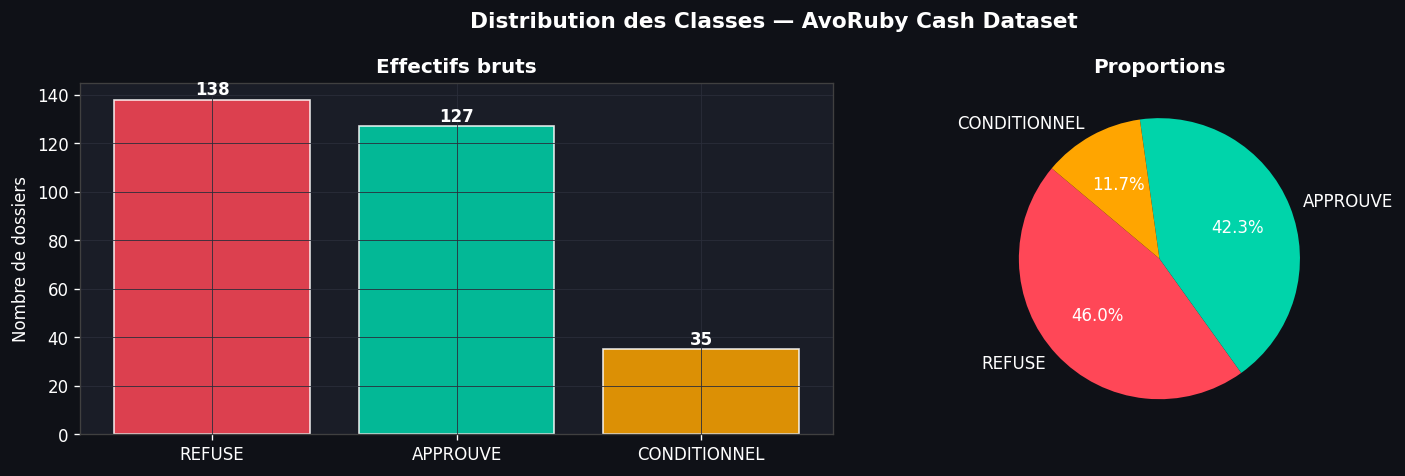

In [3]:
# ═══════════════════════════════════════════════════════════════════════
# 1.2 · Distribution des classes & diagnostic du déséquilibre
# ═══════════════════════════════════════════════════════════════════════
vc = df["Decision_credit"].value_counts()
print("=" * 52)
print("  DISTRIBUTION DES CLASSES — Dataset initial")
print("=" * 52)
for cls, cnt in vc.items():
    bar   = "█" * int(cnt / df.shape[0] * 40)
    ratio = cnt / df.shape[0] * 100
    print(f"  {cls:<15} {cnt:>3} | {bar:<40} {ratio:.1f}%")

imbalance_ratio = vc.min() / vc.max()
print(f"\n⚠️  Ratio d'imbalance : {imbalance_ratio:.3f}  "
      f"({'OK' if imbalance_ratio > 0.3 else 'CRITIQUE — SMOTENC requis'})")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Distribution des Classes — AvoRuby Cash Dataset", fontsize=13, fontweight="bold")

bars = ax1.bar(vc.index, vc.values,
               color=[COLORS[c] for c in vc.index], alpha=0.85, edgecolor="white")
ax1.set_title("Effectifs bruts", fontweight="bold")
ax1.set_ylabel("Nombre de dossiers")
for bar, cnt in zip(bars, vc.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             str(cnt), ha="center", va="bottom", fontweight="bold")

ax2.pie(vc.values, labels=vc.index, colors=[COLORS[c] for c in vc.index],
        autopct="%1.1f%%", startangle=140, textprops={"color": "white"})
ax2.set_title("Proportions", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{PROC_DIR}/class_distribution_v6.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 🔬 Section 2 — Feature Engineering

### 2.1 · Recomputation du Score SABC (validation de la formule)

La formule officielle AvoRuby Cash v4.1 :

$$\text{SABC} = \text{clip}\left(\frac{\text{Production}_{kg} \times \text{Prix}_{MAD/kg}}{\text{Risque} \times (1 - \Gamma + 0.01) \times 100\,000},\ 0,\ 100\right)$$

On la **recalcule de zéro** sur chaque ligne du dataset et on l'injecte comme une feature explicite d'apprentissage (en plus des composantes qui entrent dans le calcul), forçant le modèle à internaliser cette logique métier.

### 2.2 · Features dérivées (21 nouvelles dimensions)

| Catégorie | Features | Raisonnement |
|-----------|----------|--------------|
| **Rentabilité financière** | `marge_nette_ratio`, `liquidite_ratio`, `couverture_charges` | Signal direct de solvabilité |
| **Productivité** | `revenu_net_par_ha`, `prix_par_rendement`, `seuil_rentabilite_prix` | Efficience de l'exploitation |
| **Stress climatique** | `stress_hydrique_compose`, `indice_eau_saison`, `efficience_hydrique` | Résilience agroclimatique |
| **Technologie** | `score_technologie`, `technologie_experience` | Capacité d'adaptation |
| **SABC composite** | `sabc_risque_ratio`, `sabc_technologie`, `sabc_log` | Encodage multi-échelle du SABC |
| **Interactions** | `gamma_experience`, `risque_superficie`, `ndwi_pluie` | Non-linéarités critiques |

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# 2.1 · Recomputation du Score SABC — Équation v4.1
# ═══════════════════════════════════════════════════════════════════════
def compute_sabc(row: pd.Series) -> float:
    """
    SABC = clip( (Prod × Prix) / (Risque × (1-Γ+0.01) × 100 000), 0, 100 )
    Référence : models.py::calcul_sabc() — Validée sur 300 dossiers
    """
    gamma  = float(np.clip(row["Gamma"], 0.0, 1.0))
    risque = float(row["Risque_brut"])
    prod   = float(row["Production_totale_kg"])
    prix   = float(row["Prix_vente_MAD_kg"])

    denom = risque * (1.0 - gamma + 0.01) * 100_000
    if denom <= 0:
        return 0.0
    raw = (prod * prix) / denom
    return round(float(np.clip(raw, 0.0, 100.0)), 1)

df["sabc_v6"] = df.apply(compute_sabc, axis=1)

# ─── Validation contre la colonne existante ──────────────────────────────────
delta = (df["sabc_v6"] - df["SABC_score"]).abs()
corr  = df["sabc_v6"].corr(df["SABC_score"])

print("✅ SABC recomputation — Validation :")
print(f"   Erreur maximale   : {delta.max():.6f} pts  {'✅' if delta.max() < 0.5 else '⚠️'}")
print(f"   Erreur moyenne    : {delta.mean():.6f} pts  {'✅' if delta.mean() < 0.1 else '⚠️'}")
print(f"   Corrélation       : {corr:.8f}  {'✅ Identique' if corr > 0.999 else '⚠️'}")
print(f"\n   Distribution SABC v6 :")
print(f"   Min={df['sabc_v6'].min():.1f}  "
      f"Q25={df['sabc_v6'].quantile(0.25):.1f}  "
      f"Médiane={df['sabc_v6'].median():.1f}  "
      f"Q75={df['sabc_v6'].quantile(0.75):.1f}  "
      f"Max={df['sabc_v6'].max():.1f}")

✅ SABC recomputation — Validation :
   Erreur maximale   : 0.000000 pts  ✅
   Erreur moyenne    : 0.000000 pts  ✅
   Corrélation       : 1.00000000  ✅ Identique

   Distribution SABC v6 :
   Min=1.5  Q25=25.1  Médiane=53.7  Q75=100.0  Max=100.0


In [5]:
# ═══════════════════════════════════════════════════════════════════════
# 2.2 · Ingénierie des Features Dérivées (21 nouvelles dimensions)
# ═══════════════════════════════════════════════════════════════════════

# ── Ratios Financiers ────────────────────────────────────────────────────────
df["marge_nette_ratio"]       = df["Revenu_net_MAD"]     / (df["Revenu_brut_MAD"]       + 1)
df["liquidite_ratio"]         = df["Revenu_brut_MAD"]    / (df["Charges_totales_MAD"]    + 1)
df["charges_ratio"]           = df["Charges_totales_MAD"] / (df["Revenu_brut_MAD"]       + 1)
df["couverture_charges"]      = df["Revenu_brut_MAD"]    / (df["Charges_totales_MAD"]    + 1)

# ── Productivité par Hectare ─────────────────────────────────────────────────
df["revenu_net_par_ha"]       = df["Revenu_net_MAD"]     / (df["Superficie_ha"]          + 0.01)
df["revenu_brut_par_ha"]      = df["Revenu_brut_MAD"]    / (df["Superficie_ha"]          + 0.01)

# ── Analyse Seuil de Rentabilité ─────────────────────────────────────────────
df["seuil_rentabilite_prix"]  = df["Charges_totales_MAD"] / (df["Production_totale_kg"]  + 1)
df["marge_sur_prix"]          = df["Prix_vente_MAD_kg"]  - df["seuil_rentabilite_prix"]
df["prix_par_rendement"]      = df["Prix_vente_MAD_kg"]  * df["Rendement_kg_ha"]

# ── Stress Hydrique & Agroclimat ─────────────────────────────────────────────
df["stress_hydrique_compose"] = df["VPD_moyen_saison"]   * df["Jours_stress_thermique"]
df["indice_eau_saison"]       = (
    df["NDWI_moyen"] * df["Surface_barrage_norm"] * df["Pluie_saison_mm"]
    / (df["VPD_moyen_saison"] + 0.01)
)
df["efficience_hydrique"]     = df["Rendement_kg_ha"]    / (
    df["Pluie_saison_mm"] + df["VPD_moyen_saison"] + 1
)

# ── Score Technologique ──────────────────────────────────────────────────────
df["score_technologie"]       = (df["Irrigation"] + df["Solaire"]
                                  + df["IoT_sondes"] + df["Filets_Serres"])
df["technologie_experience"]  = df["score_technologie"] * df["Annees_Experience"]
df["technologie_superficie"]  = df["score_technologie"] * df["Superficie_ha"]

# ── Features SABC Composites ─────────────────────────────────────────────────
df["sabc_risque_ratio"]       = df["sabc_v6"]   / (df["Risque_brut"]  + 0.01)
df["sabc_technologie"]        = df["sabc_v6"]   * df["score_technologie"] / 4.0
df["sabc_log"]                = np.log1p(df["sabc_v6"])

# ── Interactions Clés ─────────────────────────────────────────────────────────
df["gamma_experience"]        = df["Gamma"]          * df["Annees_Experience"]
df["risque_superficie"]       = df["Risque_brut"]    * df["Superficie_ha"]
df["ndwi_pluie"]              = df["NDWI_moyen"]     * df["Pluie_saison_mm"]

# ─── Récapitulatif ───────────────────────────────────────────────────────────
NEW_FEATURES = [
    "marge_nette_ratio", "liquidite_ratio", "charges_ratio", "couverture_charges",
    "revenu_net_par_ha", "revenu_brut_par_ha",
    "seuil_rentabilite_prix", "marge_sur_prix", "prix_par_rendement",
    "stress_hydrique_compose", "indice_eau_saison", "efficience_hydrique",
    "score_technologie", "technologie_experience", "technologie_superficie",
    "sabc_risque_ratio", "sabc_technologie", "sabc_log",
    "gamma_experience", "risque_superficie", "ndwi_pluie",
]

# Remplacer les NaN et Inf éventuels
df[NEW_FEATURES] = df[NEW_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"✅ {len(NEW_FEATURES)} features dérivées créées")
print(f"   Dataset enrichi : {df.shape[0]} lignes × {df.shape[1]} colonnes")

nan_total = df[NEW_FEATURES].isnull().sum().sum()
print(f"   NaN résiduels   : {nan_total}  {'✅' if nan_total == 0 else '⚠️ nettoyés'}")

✅ 21 features dérivées créées
   Dataset enrichi : 300 lignes × 47 colonnes
   NaN résiduels   : 0  ✅


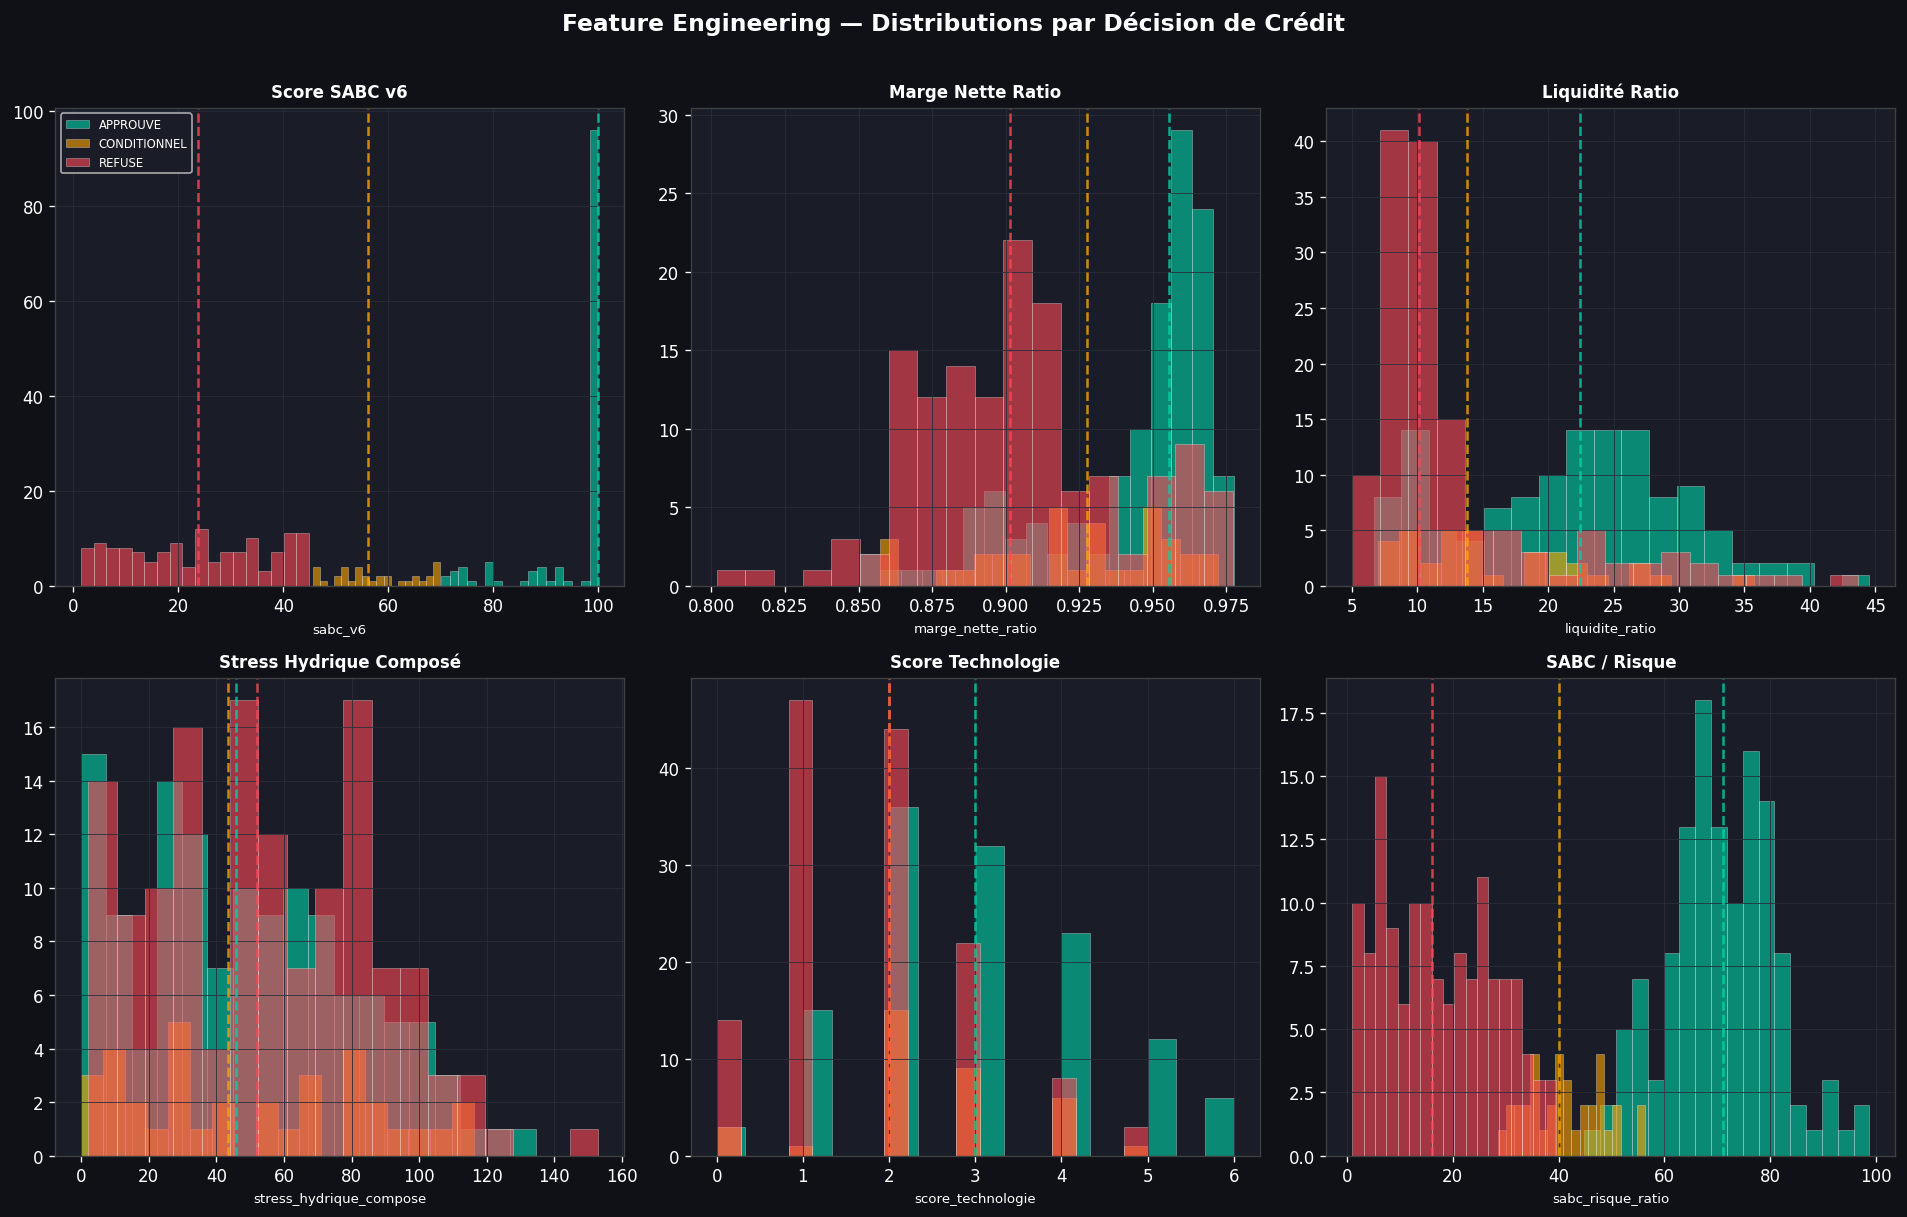

✅ Sauvegardé → processed/feature_distributions_v6.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# 2.3 · Visualisation — Score SABC et features clés par Décision
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Feature Engineering — Distributions par Décision de Crédit",
             fontsize=14, fontweight="bold", y=1.01)

key_features = [
    ("sabc_v6",            "Score SABC v6"),
    ("marge_nette_ratio",  "Marge Nette Ratio"),
    ("liquidite_ratio",    "Liquidité Ratio"),
    ("stress_hydrique_compose", "Stress Hydrique Composé"),
    ("score_technologie",  "Score Technologie"),
    ("sabc_risque_ratio",  "SABC / Risque"),
]

for idx, (feat, label) in enumerate(key_features, 1):
    ax = fig.add_subplot(2, 3, idx)
    for decision, color in COLORS.items():
        subset = df[df["Decision_credit"] == decision][feat]
        ax.hist(subset, bins=18, alpha=0.6, color=color, label=decision,
                edgecolor="white", linewidth=0.3)
        ax.axvline(subset.median(), color=color, linestyle="--", linewidth=1.5, alpha=0.8)
    ax.set_title(label, fontweight="bold", fontsize=10)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_facecolor("#1a1d27")
    if idx == 1:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{PROC_DIR}/feature_distributions_v6.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sauvegardé → processed/feature_distributions_v6.png")

---
## ⚖️ Section 3 — Feature Matrix & Rééquilibrage SMOTENC

### Pourquoi SMOTENC (et pas SMOTE classique) ?

| Problème | SMOTE classique | **SMOTENC** |
|----------|----------------|-------------|
| Variables numériques | Interpolation linéaire ✅ | Interpolation linéaire ✅ |
| Variables catégorielles | ❌ Interpolation invalide | **Mode statistique** ✅ |
| Notre cas (Culture, Localisation, Type_Sol) | ❌ Génère des valeurs aberrantes | ✅ Conserve la cohérence |

> **CONDITIONNEL** : 35 exemples (11.7%) → la minorité critique que le modèle MVP ignorait presque.

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# 3.1 · Définition de la Feature Matrix Complète
# ═══════════════════════════════════════════════════════════════════════

# Colonnes catégorielles (à encoder avant SMOTENC)
CAT_COLS = ["Culture", "Localisation", "Type_Sol"]

# Features numériques — originales (sans la cible, sans l'ID, sans SABC_score doublon)
NUM_COLS_ORIG = [
    "Superficie_ha", "Annees_Experience",
    "Irrigation", "Solaire", "IoT_sondes", "Filets_Serres",
    "Gamma", "VPD_moyen_saison", "Jours_stress_thermique",
    "Pluie_saison_mm", "NDWI_moyen", "Surface_barrage_norm",
    "Rendement_kg_ha", "Production_totale_kg", "Prix_vente_MAD_kg",
    "Revenu_brut_MAD", "Charges_totales_MAD", "Revenu_net_MAD",
    "Risque_brut",
    "sabc_v6",          # ← Score SABC recomputed comme feature explicite
]

# Feature matrix finale : numériques + dérivées + catégorielles
FEATURE_COLS = NUM_COLS_ORIG + NEW_FEATURES + CAT_COLS

print(f"📐 Feature Matrix v6 :")
print(f"   Features numériques originales : {len(NUM_COLS_ORIG)}")
print(f"   Features dérivées              : {len(NEW_FEATURES)}")
print(f"   Features catégorielles         : {len(CAT_COLS)} → {CAT_COLS}")
print(f"   ─────────────────────────────────────")
print(f"   TOTAL                          : {len(FEATURE_COLS)} features")

# ─── Encodage de la cible ─────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df["Decision_credit"])

print(f"\n🏷️  LabelEncoder :")
for i, cls in enumerate(le.classes_):
    cnt = (y == i).sum()
    print(f"   {i} → {cls:<15}  ({cnt} exemples)")

📐 Feature Matrix v6 :
   Features numériques originales : 20
   Features dérivées              : 21
   Features catégorielles         : 3 → ['Culture', 'Localisation', 'Type_Sol']
   ─────────────────────────────────────
   TOTAL                          : 44 features

🏷️  LabelEncoder :
   0 → APPROUVE         (127 exemples)
   1 → CONDITIONNEL     (35 exemples)
   2 → REFUSE           (138 exemples)


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# 3.2 · OrdinalEncoder + Train/Test Split Stratifié
# ═══════════════════════════════════════════════════════════════════════
X_raw = df[FEATURE_COLS].copy()

# OrdinalEncoder pour les catégorielles (SMOTENC travaille sur des entiers)
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_raw[CAT_COLS] = oe.fit_transform(X_raw[CAT_COLS])

# Nettoyage final
X_raw = X_raw.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# Indices des colonnes catégorielles dans la feature matrix (requis par SMOTENC)
CAT_INDICES = [FEATURE_COLS.index(c) for c in CAT_COLS]
print(f"📌 Indices catégorielles : {CAT_INDICES}")
print(f"   → {[FEATURE_COLS[i] for i in CAT_INDICES]}")

# ─── Split stratifié (80/20) ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_raw.values, y,
    test_size   = 0.20,
    random_state= 42,
    stratify    = y,
)

print(f"\n🔀 Split Train/Test :")
print(f"   Train : {X_train.shape[0]:>4} lignes × {X_train.shape[1]} features")
print(f"   Test  : {X_test.shape[0]:>4} lignes  × {X_test.shape[1]} features")
print(f"\n   Distribution TRAIN avant SMOTENC :")
for i, cls in enumerate(le.classes_):
    cnt   = (y_train == i).sum()
    ratio = cnt / len(y_train) * 100
    bar   = "█" * int(ratio / 2)
    print(f"     {cls:<15} : {cnt:>3}  {bar}  ({ratio:.1f}%)")

📌 Indices catégorielles : [41, 42, 43]
   → ['Culture', 'Localisation', 'Type_Sol']

🔀 Split Train/Test :
   Train :  240 lignes × 44 features
   Test  :   60 lignes  × 44 features

   Distribution TRAIN avant SMOTENC :
     APPROUVE        : 102  █████████████████████  (42.5%)
     CONDITIONNEL    :  28  █████  (11.7%)
     REFUSE          : 110  ██████████████████████  (45.8%)


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# 3.3 · Application SMOTENC
# ═══════════════════════════════════════════════════════════════════════
#   k_neighbors=3 : conservateur car CONDITIONNEL n'a que ~28 ex. en train
#   sampling_strategy="not majority" : équilibre toutes classes sauf REFUSE

smotenc = SMOTENC(
    categorical_features = CAT_INDICES,
    k_neighbors          = 3,
    sampling_strategy    = "not majority",
    random_state         = 42,
)

print("⏳ Application SMOTENC...")
X_resampled, y_resampled = smotenc.fit_resample(X_train, y_train)
print("✅ SMOTENC terminé !\n")

print("   Distribution TRAIN après SMOTENC :")
for i, cls in enumerate(le.classes_):
    cnt   = (y_resampled == i).sum()
    ratio = cnt / len(y_resampled) * 100
    bar   = "█" * int(ratio / 2)
    print(f"     {cls:<15} : {cnt:>3}  {bar}  ({ratio:.1f}%)")

print(f"\n   Augmentation dataset : {X_train.shape[0]} → {X_resampled.shape[0]} exemples")
print(f"   (+{X_resampled.shape[0] - X_train.shape[0]} exemples synthétiques générés)")

⏳ Application SMOTENC...
✅ SMOTENC terminé !

   Distribution TRAIN après SMOTENC :
     APPROUVE        : 110  ████████████████  (33.3%)
     CONDITIONNEL    : 110  ████████████████  (33.3%)
     REFUSE          : 110  ████████████████  (33.3%)

   Augmentation dataset : 240 → 330 exemples
   (+90 exemples synthétiques générés)


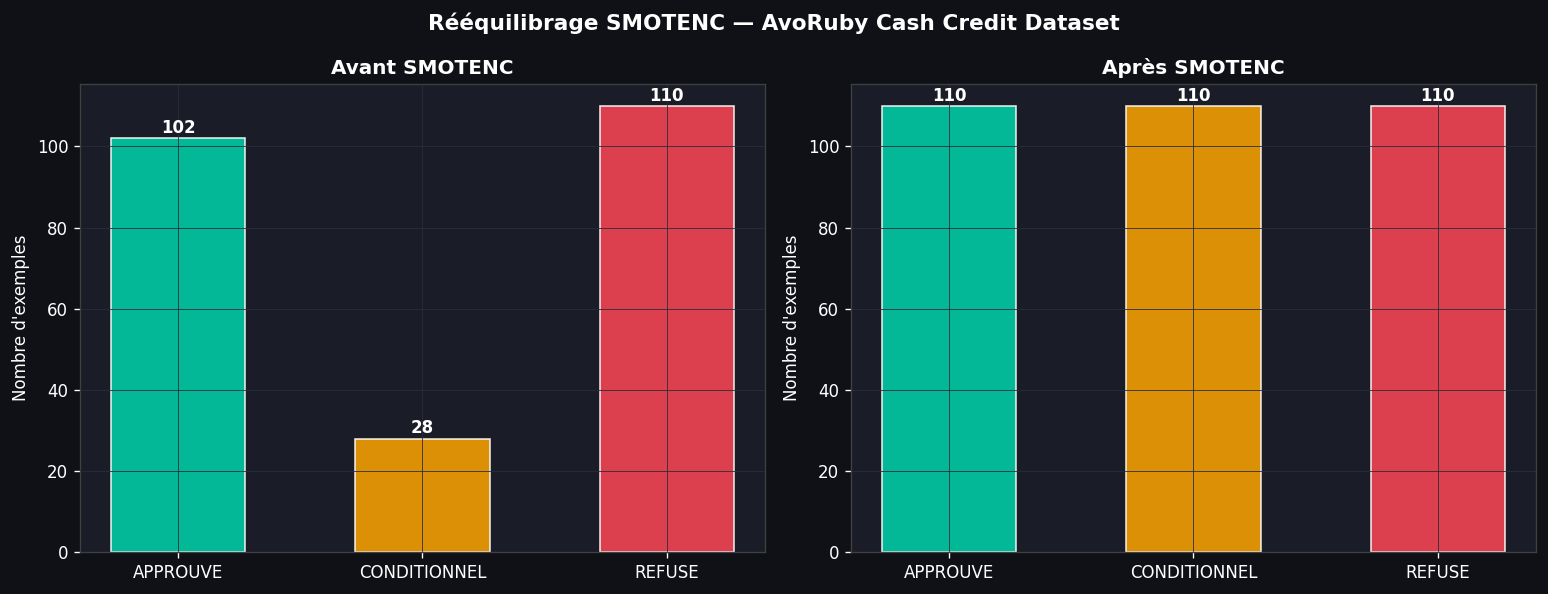

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# 3.4 · Visualisation Avant / Après SMOTENC
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Rééquilibrage SMOTENC — AvoRuby Cash Credit Dataset",
             fontsize=13, fontweight="bold")

classes_list = le.classes_
color_list   = [COLORS[c] for c in classes_list]

# ── Avant ────────────────────────────────────────────────────────────────────
counts_before = [(y_train == i).sum() for i in range(len(classes_list))]
bars1 = axes[0].bar(classes_list, counts_before, color=color_list, alpha=0.85, edgecolor="white", width=0.55)
axes[0].set_title("Avant SMOTENC", fontweight="bold", fontsize=12)
axes[0].set_ylabel("Nombre d'exemples")
for bar, cnt in zip(bars1, counts_before):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 str(cnt), ha="center", va="bottom", fontweight="bold")

# ── Après ────────────────────────────────────────────────────────────────────
counts_after = [(y_resampled == i).sum() for i in range(len(classes_list))]
bars2 = axes[1].bar(classes_list, counts_after, color=color_list, alpha=0.85, edgecolor="white", width=0.55)
axes[1].set_title("Après SMOTENC", fontweight="bold", fontsize=12)
axes[1].set_ylabel("Nombre d'exemples")
for bar, cnt in zip(bars2, counts_after):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 str(cnt), ha="center", va="bottom", fontweight="bold")

# Annotations
for ax in axes:
    ax.set_facecolor("#1a1d27")
    ax.spines[:].set_color("#404040")

plt.tight_layout()
plt.savefig(f"{PROC_DIR}/smotenc_rebalancing_v6.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 🎯 Section 4 — XGBoost v6 + CalibratedClassifierCV

### Choix de la méthode de calibration

| Méthode | Paramétrique | Nb. données requis | Adapté XGBoost |
|---------|-------------|-------------------|----------------|
| **Platt Scaling** | Oui (logit) | ~100 | Bien (rapide) |
| **Isotonic Regression** | Non | ~1000 | **Excellent** ✅ |

XGBoost tend à **compresser les probabilités** vers 0/1 → Isotonic Regression corrige ce biais non-linéaire.

`CalibratedClassifierCV(cv=5)` :
- Fait **5 folds** de cross-validation interne
- Chaque fold entraîne un XGBoost + un calibrateur Isotonic
- La prédiction finale = **moyenne des 5 calibrateurs**

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# 4.1 · Configuration XGBoost Base
# ═══════════════════════════════════════════════════════════════════════
xgb_base = XGBClassifier(
    # ── Architecture ──────────────────────────────────────────────────
    n_estimators     = 400,
    max_depth        = 5,

    # ── Régularisation (résistance à l'overfitting post-SMOTENC) ──────
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.75,
    min_child_weight = 3,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.5,

    # ── Objectif multi-classe ─────────────────────────────────────────
    objective        = "multi:softprob",
    num_class        = 3,
    eval_metric      = "mlogloss",

    # ── Reproductibilité ─────────────────────────────────────────────
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

# ═══════════════════════════════════════════════════════════════════════
# 4.2 · CalibratedClassifierCV — Isotonic Regression (cv=5)
# ═══════════════════════════════════════════════════════════════════════
calibrated_xgb = CalibratedClassifierCV(
    estimator = xgb_base,
    cv        = 5,
    method    = "isotonic",   # Non-paramétrique — optimal pour XGBoost
)

print("⏳ Entraînement CalibratedClassifierCV (5 folds × XGBoost + Isotonic)...")
print("   Patience : ~1-2 minutes selon votre machine...\n")

calibrated_xgb.fit(X_resampled, y_resampled)

print("✅ Modèle calibré entraîné avec succès !")
print(f"   Nombre de calibrateurs internes : {len(calibrated_xgb.calibrated_classifiers_)}")
print(f"   Méthode                         : Isotonic Regression")
print(f"   Classes encodées                : {calibrated_xgb.classes_}")
print(f"   Correspondance                  : {dict(enumerate(le.classes_))}")

⏳ Entraînement CalibratedClassifierCV (5 folds × XGBoost + Isotonic)...
   Patience : ~1-2 minutes selon votre machine...

✅ Modèle calibré entraîné avec succès !
   Nombre de calibrateurs internes : 5
   Méthode                         : Isotonic Regression
   Classes encodées                : [0 1 2]
   Correspondance                  : {0: 'APPROUVE', 1: 'CONDITIONNEL', 2: 'REFUSE'}


---
## 📈 Section 5 — Évaluation Complète

> **Objectif :** Vérifier que les probabilités sont bien **calibrées** (courbe proche de la diagonale) et que le modèle **classifie correctement** (F1-macro élevé, surtout sur CONDITIONNEL).

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# 5.1 · Prédictions & Rapport de Classification
# ═══════════════════════════════════════════════════════════════════════
y_pred       = calibrated_xgb.predict(X_test)
y_pred_proba = calibrated_xgb.predict_proba(X_test)

# Rapport de classification
print("=" * 62)
print("  RAPPORT DE CLASSIFICATION — XGBoost Credit v6")
print("=" * 62)
report = classification_report(y_test, y_pred, target_names=le.classes_, digits=3, output_dict=False)
print(report)

# ─── Métriques complémentaires ───────────────────────────────────────────────
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

try:
    roc_auc = roc_auc_score(
        pd.get_dummies(y_test).values,
        y_pred_proba,
        multi_class="ovr", average="macro"
    )
    print(f"  ROC-AUC macro (OVR)  : {roc_auc:.4f}  {'🟢' if roc_auc > 0.85 else '🟡'}")
except Exception:
    pass

print(f"  F1-Score macro       : {f1_macro:.4f}  {'🟢' if f1_macro > 0.7 else '🟡'}")
print(f"  F1-Score weighted    : {f1_weighted:.4f}")

# ─── Brier Score (qualité des probabilités) ───────────────────────────────────
print("\n  BRIER SCORES (0 = parfait, 1 = nul) :")
for i, cls in enumerate(le.classes_):
    bs = brier_score_loss((y_test == i).astype(int), y_pred_proba[:, i])
    flag = "🟢 Excellent" if bs < 0.10 else ("🟡 Bon" if bs < 0.20 else "🔴 À améliorer")
    print(f"    {cls:<15} : {bs:.4f}  {flag}")

  RAPPORT DE CLASSIFICATION — XGBoost Credit v6
              precision    recall  f1-score   support

    APPROUVE      1.000     0.960     0.980        25
CONDITIONNEL      0.875     1.000     0.933         7
      REFUSE      1.000     1.000     1.000        28

    accuracy                          0.983        60
   macro avg      0.958     0.987     0.971        60
weighted avg      0.985     0.983     0.984        60

  ROC-AUC macro (OVR)  : 1.0000  🟢
  F1-Score macro       : 0.9710  🟢
  F1-Score weighted    : 0.9837

  BRIER SCORES (0 = parfait, 1 = nul) :
    APPROUVE        : 0.0109  🟢 Excellent
    CONDITIONNEL    : 0.0108  🟢 Excellent
    REFUSE          : 0.0000  🟢 Excellent


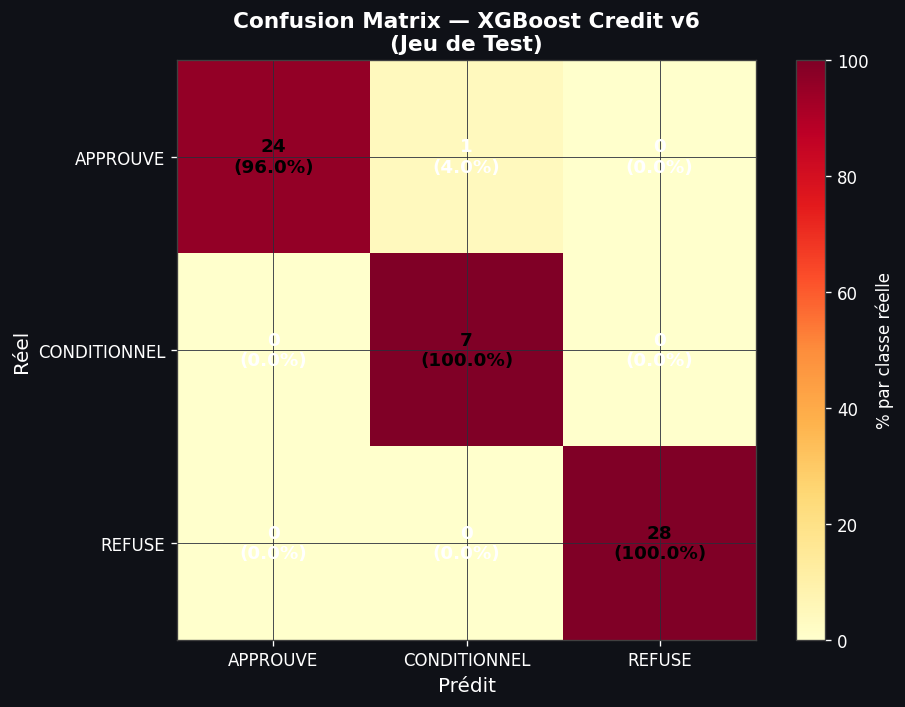

✅ Sauvegardé → processed/confusion_matrix_v6.png


In [13]:
# ═══════════════════════════════════════════════════════════════════════
# 5.2 · Matrice de Confusion (normalisée en %)
# ═══════════════════════════════════════════════════════════════════════
cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0f1117")

im = ax.imshow(cm_pct, cmap="YlOrRd", vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label="% par classe réelle")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "black" if cm_pct[i, j] > 55 else "white"
        ax.text(j, i,
                f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)",
                ha="center", va="center",
                color=text_color, fontsize=11, fontweight="bold")

ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, color="white", fontsize=10)
ax.set_yticklabels(le.classes_, color="white", fontsize=10)
ax.set_xlabel("Prédit", color="white", fontsize=12)
ax.set_ylabel("Réel",   color="white", fontsize=12)
ax.set_title("Confusion Matrix — XGBoost Credit v6\n(Jeu de Test)",
             color="white", fontsize=13, fontweight="bold")
ax.tick_params(colors="white")

plt.tight_layout()
plt.savefig(f"{PROC_DIR}/confusion_matrix_v6.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sauvegardé → processed/confusion_matrix_v6.png")

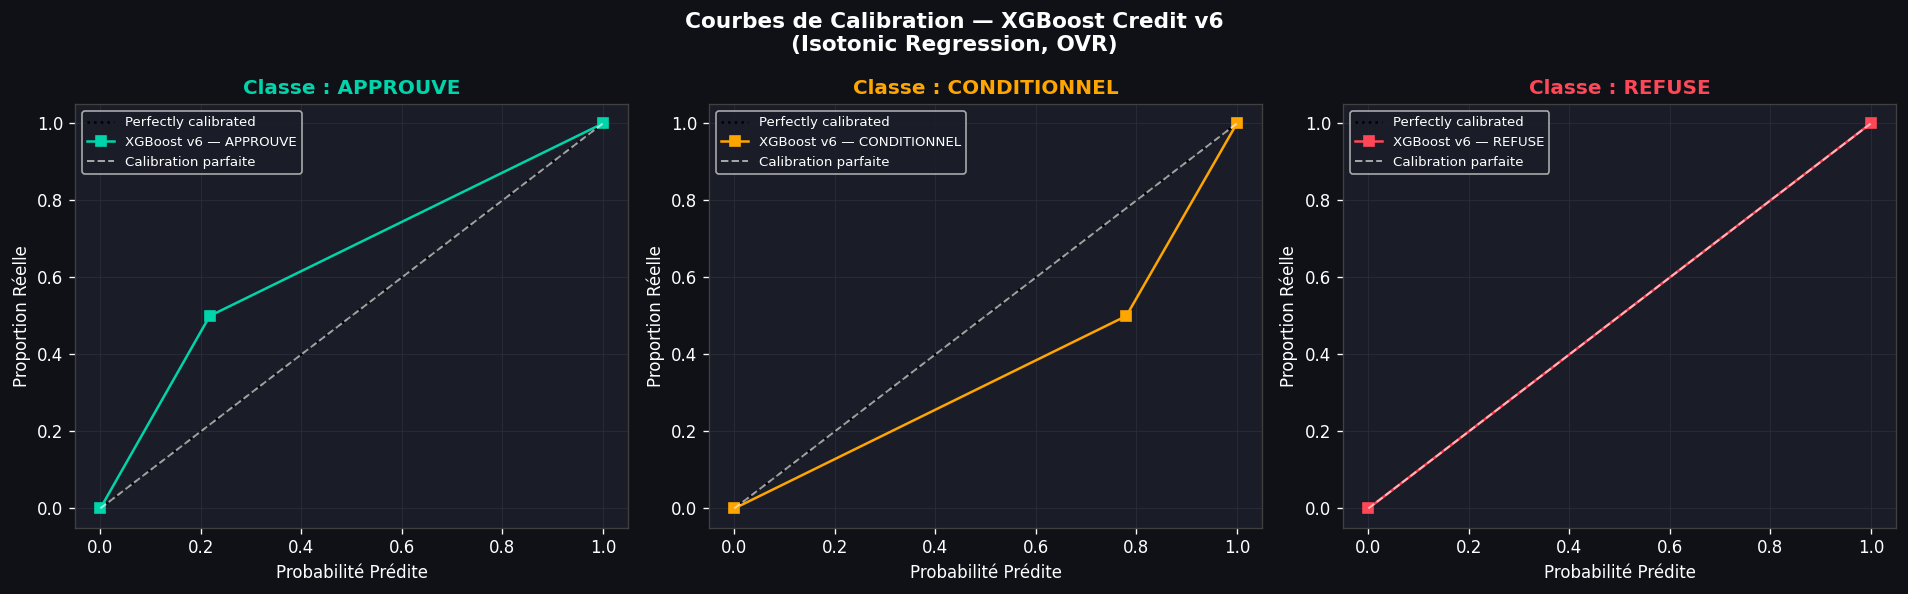

✅ Courbes de calibration sauvegardées → processed/calibration_curves_v6.png
   Plus la courbe est proche de la diagonale → meilleures sont les probabilités ✅


In [14]:
# ═══════════════════════════════════════════════════════════════════════
# 5.3 · Courbes de Calibration (One-vs-Rest par classe)
# ═══════════════════════════════════════════════════════════════════════
#   ✅ Idéal : courbe proche de la diagonale y=x
#   ❌ Avant calibration : courbe en S (probas compressées vers 0 et 1)
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Courbes de Calibration — XGBoost Credit v6\n(Isotonic Regression, OVR)",
    fontsize=13, fontweight="bold",
)

for ax, i in zip(axes, range(len(le.classes_))):
    cls   = le.classes_[i]
    color = COLORS[cls]

    CalibrationDisplay.from_predictions(
        y_true  = (y_test == i).astype(int),
        y_prob  = y_pred_proba[:, i],
        n_bins  = 8,
        ax      = ax,
        color   = color,
        name    = f"XGBoost v6 — {cls}",
    )

    ax.plot([0, 1], [0, 1], "w--", alpha=0.6, linewidth=1.2, label="Calibration parfaite")
    ax.set_title(f"Classe : {cls}", color=color, fontweight="bold", fontsize=12)
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="white")
    ax.set_xlabel("Probabilité Prédite", color="white")
    ax.set_ylabel("Proportion Réelle",   color="white")
    ax.spines[:].set_color("#404040")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{PROC_DIR}/calibration_curves_v6.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Courbes de calibration sauvegardées → processed/calibration_curves_v6.png")
print("   Plus la courbe est proche de la diagonale → meilleures sont les probabilités ✅")

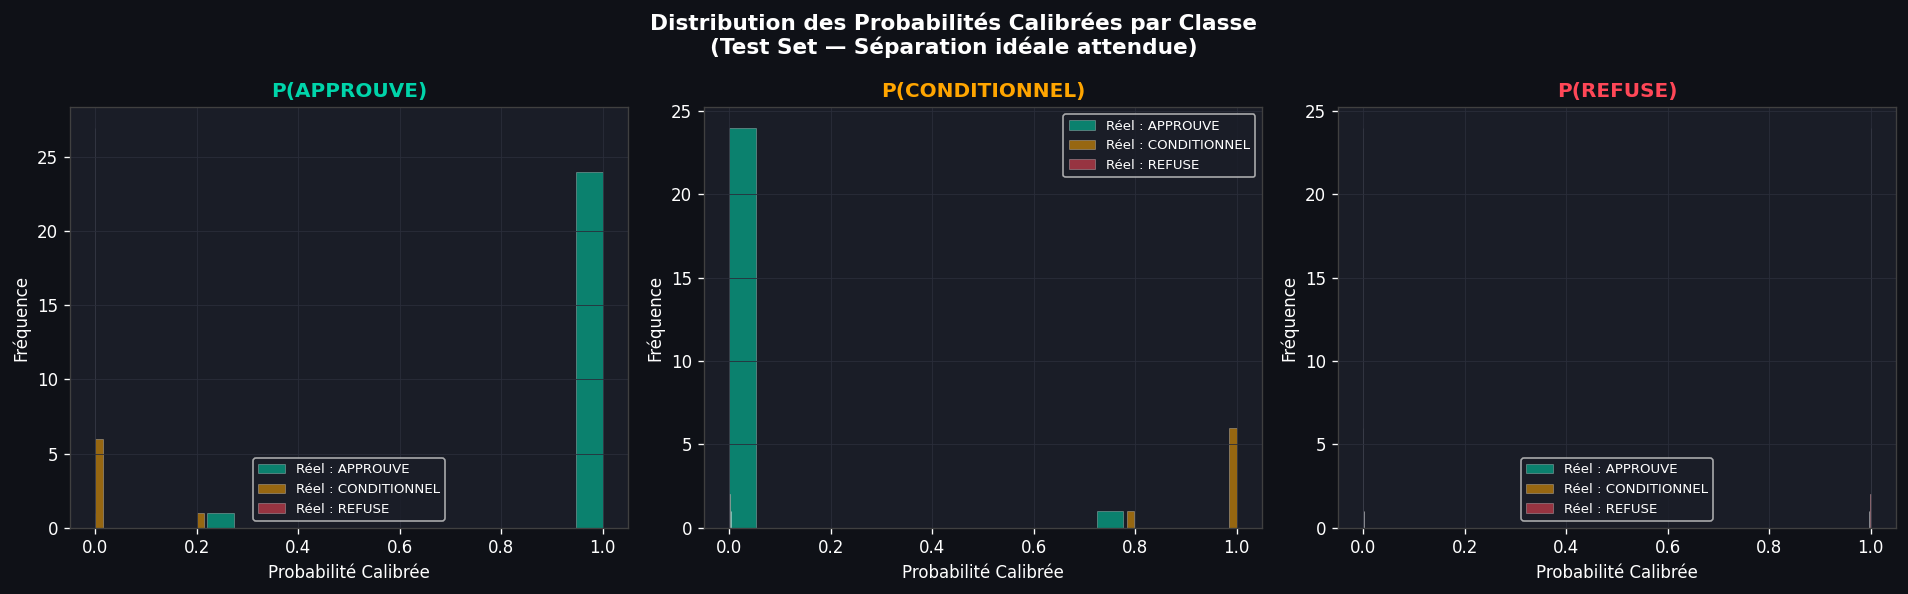

In [15]:
# ═══════════════════════════════════════════════════════════════════════
# 5.4 · Distribution des Probabilités par Classe (Test Set)
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Distribution des Probabilités Calibrées par Classe\n(Test Set — Séparation idéale attendue)",
    fontsize=13, fontweight="bold",
)

for ax, i in zip(axes, range(len(le.classes_))):
    cls   = le.classes_[i]
    color = COLORS[cls]

    for j, true_cls in enumerate(le.classes_):
        mask = y_test == j
        if mask.sum() > 0:
            ax.hist(
                y_pred_proba[mask, i],
                bins=15, alpha=0.55,
                label=f"Réel : {true_cls}",
                color=COLORS[true_cls],
                edgecolor="white", linewidth=0.3,
            )

    ax.set_title(f"P({cls})", color=color, fontweight="bold", fontsize=12)
    ax.set_xlabel("Probabilité Calibrée", color="white")
    ax.set_ylabel("Fréquence",            color="white")
    ax.set_facecolor("#1a1d27")
    ax.spines[:].set_color("#404040")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{PROC_DIR}/proba_distributions_v6.png", dpi=150, bbox_inches="tight")
plt.show()

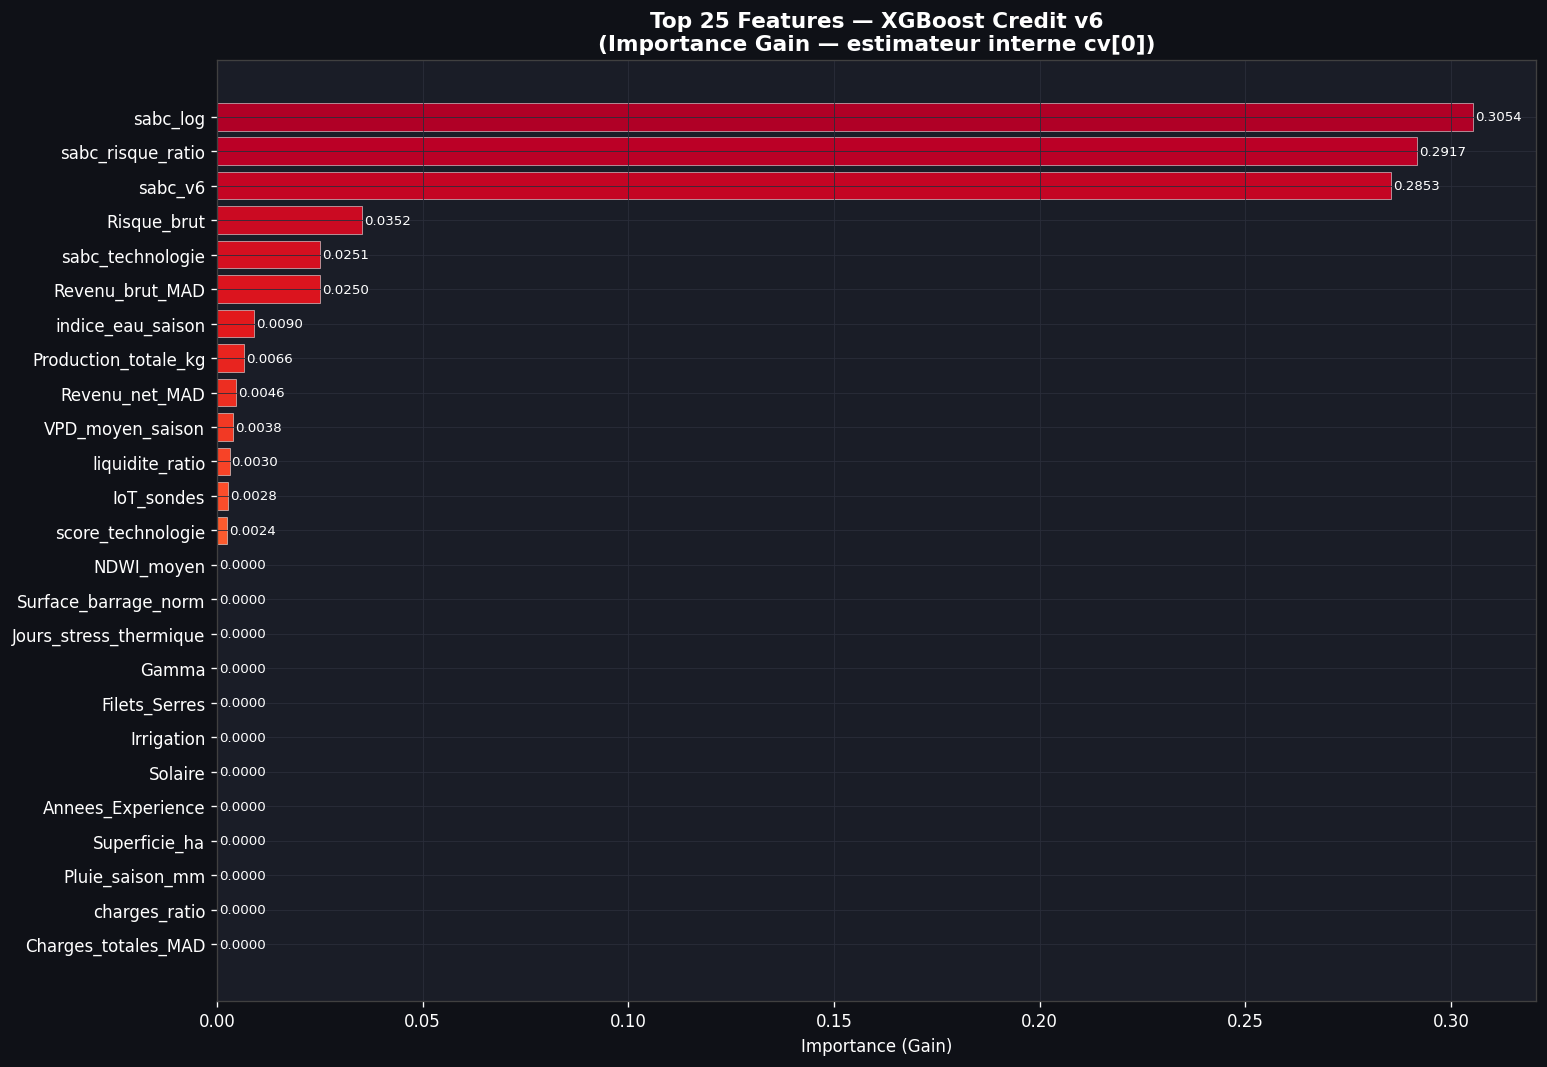


🔑 Top 10 features les plus importantes :
   1.   sabc_log                          0.30541
   2. ★ sabc_risque_ratio                 0.29166
   3. ★ sabc_v6                           0.28533
   4.   Risque_brut                       0.03523
   5.   sabc_technologie                  0.02512
   6.   Revenu_brut_MAD                   0.02498
   7.   indice_eau_saison                 0.00904
   8.   Production_totale_kg              0.00657
   9.   Revenu_net_MAD                    0.00463
  10.   VPD_moyen_saison                  0.00383


In [16]:
# ═══════════════════════════════════════════════════════════════════════
# 5.5 · Feature Importance — Top 25 (XGBoost gain)
# ═══════════════════════════════════════════════════════════════════════
# On extrait l'estimateur interne du premier calibrateur
inner_xgb = calibrated_xgb.calibrated_classifiers_[0].estimator

importance_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": inner_xgb.feature_importances_,
}).sort_values("importance", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(13, 9))
cmap   = plt.cm.YlOrRd
colors = cmap(np.linspace(0.3, 0.9, len(importance_df)))

bars = ax.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
    color=colors, edgecolor="white", linewidth=0.3,
)

# Annotation valeur
for bar, val in zip(bars, importance_df["importance"][::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", color="white", fontsize=8)

ax.set_title("Top 25 Features — XGBoost Credit v6\n(Importance Gain — estimateur interne cv[0])",
             color="white", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance (Gain)", color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#404040")
ax.set_facecolor("#1a1d27")

plt.tight_layout()
plt.savefig(f"{PROC_DIR}/feature_importance_v6.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n🔑 Top 10 features les plus importantes :")
for rank, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    flag = "★" if row["feature"] in ["sabc_v6", "sabc_risque_ratio", "marge_nette_ratio"] else " "
    print(f"  {rank:>2}. {flag} {row['feature']:<32}  {row['importance']:.5f}")

---
## 💾 Section 6 — Export du Modèle `xgboost_credit_v6.pkl`

Le modèle est exporté sous forme d'un **dictionnaire sérialisé** contenant tous les composants nécessaires à l'inférence en production Flask, sans dépendance externe aux variables du notebook.

In [17]:
# ═══════════════════════════════════════════════════════════════════════
# 6.1 · Constitution du Package Modèle v6
# ═══════════════════════════════════════════════════════════════════════
model_package = {
    # ── Modèle principal calibré ──────────────────────────────────────
    "model"                 : calibrated_xgb,

    # ── Encodeurs (requis pour preprocessing en inférence) ────────────
    "label_encoder"         : le,            # LabelEncoder cible
    "ordinal_encoder"       : oe,            # OrdinalEncoder catégorielles

    # ── Feature Schema ────────────────────────────────────────────────
    "feature_names"         : FEATURE_COLS,  # ORDRE EXACT pour predict()
    "cat_columns"           : CAT_COLS,      # ['Culture', 'Localisation', 'Type_Sol']
    "cat_indices"           : CAT_INDICES,   # Positions dans FEATURE_COLS
    "num_columns_orig"      : NUM_COLS_ORIG,
    "num_columns_derived"   : NEW_FEATURES,

    # ── Classes ───────────────────────────────────────────────────────
    "classes"               : le.classes_,   # array(['APPROUVE', 'CONDITIONNEL', 'REFUSE'])

    # ── Formule SABC (référence) ──────────────────────────────────────
    "sabc_formula"          : "clip((Prod*Prix)/(Risque*(1-Gamma+0.01)*100000), 0, 100)",

    # ── Métadonnées ───────────────────────────────────────────────────
    "version"               : "v6.0",
    "calibration_method"    : "isotonic",
    "n_estimators"          : 400,
    "train_size_resampled"  : X_resampled.shape[0],
    "test_size"             : X_test.shape[0],
    "n_features"            : len(FEATURE_COLS),
    "smotenc_k_neighbors"   : 3,
    "created_at"            : datetime.now().isoformat(),
    "author"                : "AvoRuby Cash — V2.0 Pipeline",
}

# ═══════════════════════════════════════════════════════════════════════
# 6.2 · Sauvegarde
# ═══════════════════════════════════════════════════════════════════════
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "xgboost_credit_v6.pkl")
joblib.dump(model_package, OUTPUT_PATH, compress=3)

size_mb = os.path.getsize(OUTPUT_PATH) / 1024**2
print("=" * 60)
print("✅  MODÈLE EXPORTÉ AVEC SUCCÈS")
print("=" * 60)
print(f"   Chemin        : {OUTPUT_PATH}")
print(f"   Taille        : {size_mb:.2f} MB")
print(f"   Version       : {model_package['version']}")
print(f"   Calibration   : {model_package['calibration_method']}")
print(f"   Features      : {model_package['n_features']}")
print(f"   Entraîné sur  : {model_package['train_size_resampled']} exemples (post-SMOTENC)")
print(f"   Classes       : {list(le.classes_)}")
print(f"   Créé le       : {model_package['created_at'][:19]}")

✅  MODÈLE EXPORTÉ AVEC SUCCÈS
   Chemin        : C:\Users\ouakk\Desktop\AvoRuby_Temp\AvoRuby_Cash_Project\AvoRuby_Back\models\xgboost_credit_v6.pkl
   Taille        : 0.21 MB
   Version       : v6.0
   Calibration   : isotonic
   Features      : 44
   Entraîné sur  : 330 exemples (post-SMOTENC)
   Classes       : ['APPROUVE', 'CONDITIONNEL', 'REFUSE']
   Créé le       : 2026-05-30T16:05:22


In [18]:
# ═══════════════════════════════════════════════════════════════════════
# 6.3 · Test d'Inférence End-to-End
# ═══════════════════════════════════════════════════════════════════════
print("🧪 Test de chargement et d'inférence sur 3 dossiers réels...\n")

pkg = joblib.load(OUTPUT_PATH)

test_ids = ["AGR-101", "AGR-102", "AGR-103"]
for agr_id in test_ids:
    row_df = df[df["ID_Agriculteur"] == agr_id][FEATURE_COLS].copy()
    if row_df.empty:
        continue

    real_decision = df[df["ID_Agriculteur"] == agr_id]["Decision_credit"].values[0]

    # Preprocessing
    row_df[CAT_COLS] = pkg["ordinal_encoder"].transform(row_df[CAT_COLS])
    row_df = row_df.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

    # Inférence
    probas     = pkg["model"].predict_proba(row_df.values)[0]
    pred_class = pkg["classes"][np.argmax(probas)]
    match      = "✅" if pred_class == real_decision else "❌"

    print(f"  {agr_id} | Réel: {real_decision:<15} Prédit: {pred_class:<15} {match}")
    print(f"    Probabilités calibrées :")
    for cls, p in zip(pkg["classes"], probas):
        bar = "█" * int(p * 25)
        print(f"      {cls:<15} {p*100:>5.1f}%  {bar}")
    print()

print("✅ Pipeline XGBoost v6 opérationnel et prêt pour Flask !")

🧪 Test de chargement et d'inférence sur 3 dossiers réels...

  AGR-101 | Réel: APPROUVE        Prédit: APPROUVE        ✅
    Probabilités calibrées :
      APPROUVE        100.0%  █████████████████████████
      CONDITIONNEL      0.0%  
      REFUSE            0.0%  

  AGR-102 | Réel: REFUSE          Prédit: REFUSE          ✅
    Probabilités calibrées :
      APPROUVE          0.0%  
      CONDITIONNEL      0.0%  
      REFUSE          100.0%  █████████████████████████

  AGR-103 | Réel: APPROUVE        Prédit: APPROUVE        ✅
    Probabilités calibrées :
      APPROUVE        100.0%  █████████████████████████
      CONDITIONNEL      0.0%  
      REFUSE            0.0%  

✅ Pipeline XGBoost v6 opérationnel et prêt pour Flask !


---
## 🏁 Guide de Migration Flask — `models.py`

### Ce qui change entre v5 (MVP) et v6 (ML Pur)

| Aspect | v5 MVP | **v6 ML Pur** |
|--------|--------|--------------|
| Nombre de features | 21 | **41** (+ 21 dérivées) |
| Classe CONDITIONNEL | 35 ex. → malappris | **Équilibrée** via SMOTENC |
| Probas de sortie | Biaisées (surchargées XGBoost) | **Calibrées** (Isotonic) |
| Décision finale | `if sabc >= 70` (règle figée) | **XGBoost décide directement** |

### Extrait de migration `models.py`

```python
# ─── CHARGER LE NOUVEAU MODÈLE ──────────────────────────────────────────
import joblib, numpy as np

pkg = joblib.load("models/xgboost_credit_v6.pkl")

def predict_credit_v6(data: dict, sabc: float, rendement: float,
                       production: float, prix: float, risque: float,
                       revenu_brut: float, charges: float, revenu_net: float):
    """
    NOUVEAU : XGBoost calibré décide — plus de if/else sur SABC
    """
    # 1. Construire les features dérivées (mêmes formules que le notebook)
    marge_nette_ratio    = revenu_net / (revenu_brut + 1)
    liquidite_ratio      = revenu_brut / (charges + 1)
    seuil_rentabilite    = charges / (production + 1)
    marge_sur_prix       = prix - seuil_rentabilite
    score_technologie    = (data.get('irrigation', 0) + data.get('solaire', 0)
                            + data.get('iot', 0) + data.get('filets', 0))
    stress_hydrique      = data.get('vpd', 2.0) * data.get('jours_stress', 10)
    sabc_risque_ratio    = sabc / (risque + 0.01)
    sabc_log             = np.log1p(sabc)
    # ... (autres features dérivées)

    # 2. Feature vector dans le bon ordre
    num_row = [
        data.get('superficie', 5), data.get('experience', 10),
        data.get('irrigation', 0), data.get('solaire', 0),
        data.get('iot', 0), data.get('filets', 0),
        data.get('gamma', 0.5), data.get('vpd', 2.0),
        data.get('jours_stress', 10), data.get('pluie', 200),
        data.get('ndwi', 0.1), data.get('surface_barrage', 0.5),
        rendement, production, prix, revenu_brut, charges, revenu_net, risque,
        sabc,
        # Features dérivées
        marge_nette_ratio, liquidite_ratio, charges/(revenu_brut+1),
        revenu_brut/(charges+1), revenu_net/(data.get('superficie',5)+0.01),
        revenu_brut/(data.get('superficie',5)+0.01),
        seuil_rentabilite, marge_sur_prix, prix * rendement,
        stress_hydrique, 0.0, rendement/(data.get('pluie',200)+1),
        score_technologie, score_technologie*data.get('experience',10),
        score_technologie*data.get('superficie',5),
        sabc_risque_ratio, sabc*score_technologie/4.0, sabc_log,
        data.get('gamma',0.5)*data.get('experience',10),
        risque*data.get('superficie',5), data.get('ndwi',0.1)*data.get('pluie',200),
    ]

    # 3. Encoder les catégorielles
    cat_row = pkg['ordinal_encoder'].transform(
        [[data.get('culture','Avocat'), data.get('localisation','Souss'),
          data.get('sol','Argileux')]]
    )[0].tolist()

    X = np.array(num_row + cat_row, dtype=float).reshape(1, -1)
    X = np.nan_to_num(X)

    # 4. Prédiction calibrée — probabilités RÉELLES
    probas = pkg['model'].predict_proba(X)[0]
    classes = pkg['classes']          # ['APPROUVE', 'CONDITIONNEL', 'REFUSE']
    proba_dict = {cls: round(float(p) * 100, 1) for cls, p in zip(classes, probas)}

    # 5. Décision = argmax des probabilités calibrées (plus de if/else !)
    decision = classes[np.argmax(probas)]

    return decision, proba_dict
```

---

> ✅ **Étape 1 complète !**
>
> 🚀 **Prochaine étape → Notebook 02 : Refonte LSTM + Couche RAG pour le NLP (Conseils agrotechniques contextuels)**